Question 1: What is Simple Linear Regression?
- Simple Linear Regression is a statistical method used to model the linear relationship between two continuous variables. It examines how the value of one variable can be used to predict the value of another. The relationship is represented by a straight line, known as the "line of best fit," that minimizes the distance between the observed data points and the line itself.

  - Formula for simple linear regression line is y=mx+c
    - where m is slope and c is intercept

---
Question 2: What are the key assumptions of Simple Linear Regression?
- The key assumptions of simple linear regression are:
  - Linearity: The relationship between the independent variable (X) and the dependent variable (Y) is linear.
  - Independence: The observations (and their corresponding errors) are independent of each other.
  - Homoscedasticity: The variance of the errors is constant across all levels of the independent variable.
  - Normality: For any given value of the independent variable, the dependent variable is normally distributed. Equivalently, the errors are normally distributed.

---
Question 3: What is heteroscedasticity, and why is it important to address in regression models?
- Heteroscedasticity is a situation in regression analysis where the variance of the error terms is not constant across all levels of the independent variables. It is important to address in regression models because it violates a key assumption of standard linear regression, leading to inefficient parameter estimates and unreliable standard errors, which invalidates confidence intervals and hypothesis tests. This makes the model's results less trustworthy and conclusions less valid.

- Heteroscedasticity is important to address in regression models because:
  - Inefficient estimates: While the coefficient estimates are still unbiased, they are no longer the most efficient (meaning they don't have the minimum possible variance).
  - Unreliable standard errors: Heteroscedasticity causes the standard errors to be either underestimated or overestimated. This makes them inaccurate and unreliable.
  - Invalid inference: Inaccurate standard errors lead to incorrect t-statistics and F-statistics, which invalidates hypothesis tests and confidence intervals. This can lead to incorrectly rejecting or failing to reject the null hypothesis.
  - Inaccurate conclusions: Because the model's statistical significance is unreliable, the conclusions drawn from the analysis may be invalid.

---
Question 4: What is Multiple Linear Regression?
- Multiple linear regression is a statistical technique used to predict the value of a dependent variable based on two or more independent variables. It models the linear relationship between a single outcome and multiple predictors, helping to understand how each predictor influences the outcome and to make more accurate predictions than simple linear regression.

  - represented by equation y=m1x1 +m2x2 +m3x3 + ... +mnxn + c
  - Where m1,m2,m3,...,mn is slope of multiple line
  - c is intercept
  - x1,x2,x3,...,xn is independent variable
  - y is depended variable

---
Question 5: What is polynomial regression, and how does it differ from linear regression?
- Polynomial regression models a non-linear relationship between variables by adding polynomial terms (x^2,x^3), etc. to the independent variables, while linear regression models a straight-line relationship (y=mx+b). The key difference is that polynomial regression can capture curved trends by using higher-degree polynomials, making it more flexible, whereas linear regression is limited to straight lines and may underfit the data when the relationship is non-linear.

- Difference between polynomial regression and linear regression is:
  - Linear Regression models a straight-line relationship between the independent and dependent variables while Polynomial Regression models a curved or non-linear relationship between the variables.
  - The equation for Linear Regression is y=mx +c while The equation for Polynomial Regression is y=m1x^1 +m2x^2 +m3x^3 + ... +mnx^n + c
  - Linear Regression uses only one degree of X (first power) while Polynomial Regression uses higher powers of X.
  - Polynomial Regression uses higher powers of X while Polynomial Regression fits a smooth curve through the data points.
  - Linear Regression is suitable when the relationship between variables is linear while Polynomial Regression is suitable when the relationship between variables is non-linear.
  - Linear Regression is simpler and easier to interpret while Polynomial Regression is more flexible but can become complex and prone to overfitting.

---


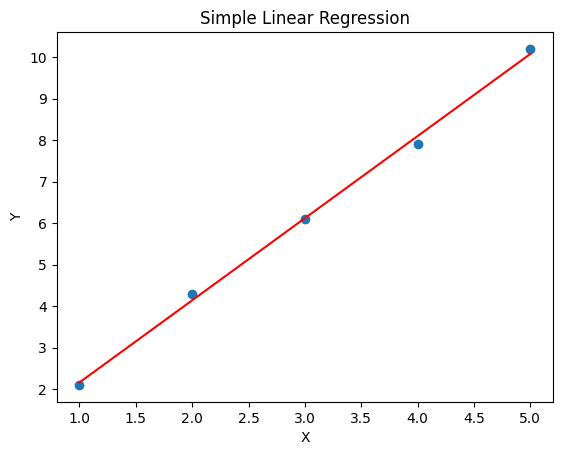

In [4]:
'''
Question 6: Implement a Python program to fit a Simple Linear Regression model
to the following sample data:
● X = [1, 2, 3, 4, 5]
● Y = [2.1, 4.3, 6.1, 7.9, 10.2]
Plot the regression line over the data points.
(Include your Python code and output in the code box below.)
Answer:
'''
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

model = LinearRegression()
model.fit(X,Y)

plt.scatter(X,Y)
plt.plot(X,model.predict(X),color='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Simple Linear Regression')
plt.show()


In [11]:
'''
Question 7: Fit a Multiple Linear Regression model on this sample data:
● Area = [1200, 1500, 1800, 2000]
● Rooms = [2, 3, 3, 4]
● Price = [250000, 300000, 320000, 370000]
Check for multicollinearity using VIF and report the results.
(Include your Python code and output in the code box below.)
Answer:

'''

from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

Area = [1200, 1500, 1800, 2000]
Rooms = [2, 3, 3, 4]
Price = [250000, 300000, 320000, 370000]

data={'Area':Area,'Rooms':Rooms,'Price':Price}
df=pd.DataFrame(data)
x=df.drop('Price',axis=1)
y=df['Price']
model= LinearRegression()
model.fit(x,y)

print(f"Model coefiecient :\n 1 > {model.coef_[0]} \n 2 > {model.coef_[1]}")
print(f"Model intercept : {model.intercept_}")

# Add constant term for VIF calculation
x_with_const = sm.add_constant(x)

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["Feature"] = x_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(x_with_const.values, i)
                   for i in range(x_with_const.shape[1])]

print("\nVariance Inflation Factor (VIF) Results:")
print(vif_data)

Model coefiecient :
 1 > 63.15789473684211 
 2 > 34736.842105263146
Model intercept : 103157.89473684214

Variance Inflation Factor (VIF) Results:
  Feature        VIF
0   const  34.210526
1    Area   7.736842
2   Rooms   7.736842


Model coefiecient : [0.   1.94 0.2 ] 
Model intercept : 0.06000000000000938


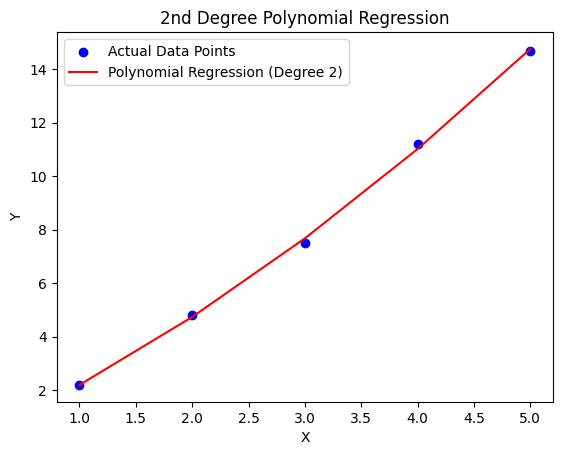

In [13]:
'''
Question 8: Implement polynomial regression on the following data:
● X = [1, 2, 3, 4, 5]
● Y = [2.2, 4.8, 7.5, 11.2, 14.7]
Fit a 2nd-degree polynomial and plot the resulting curve.
(Include your Python code and output in the code box below.)
Answer:
'''
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

X = np.array([1, 2, 3, 4, 5]).reshape(-1,1)
Y = np.array([2.2, 4.8, 7.5, 11.2, 14.7])

poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(X)

model=LinearRegression()
model.fit(x_poly,Y)

print(f"Model coefiecient : {model.coef_} ")
print(f"Model intercept : {model.intercept_}")

Y_pred= model.predict(x_poly)
plt.scatter(X, Y, color='blue', label='Actual Data Points')
plt.plot(X, Y_pred, color='red', label='Polynomial Regression (Degree 2)')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("2nd Degree Polynomial Regression")
plt.legend()
plt.show()

Intercept : 6.499999999999993
Slope : 1.1500000000000001
Residuals: [-3.   5.5 -1.  -2.5  1. ]


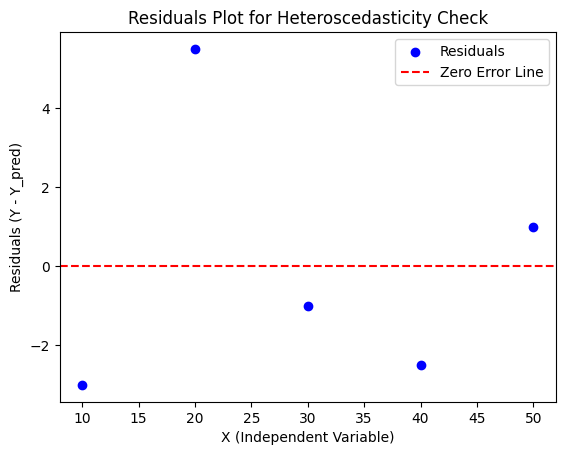

In [14]:
'''
Question 9: Create a residuals plot for a regression model trained on this data:
● X = [10, 20, 30, 40, 50]
● Y = [15, 35, 40, 50, 65]
Assess heteroscedasticity by examining the spread of residuals.
(Include your Python code and output in the code box below.)
Answer:
'''

from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)
Y = np.array([15, 35, 40, 50, 65])

model = LinearRegression()
model.fit(X, Y)

Y_pred = model.predict(X)

residuals = Y - Y_pred

print("Intercept :", model.intercept_)
print("Slope :", model.coef_[0])
print("Residuals:", residuals)

plt.scatter(X, residuals, color='blue', label='Residuals')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Error Line')
plt.xlabel("X (Independent Variable)")
plt.ylabel("Residuals (Y - Y_pred)")
plt.title("Residuals Plot for Heteroscedasticity Check")
plt.legend()
plt.show()

---

Question 10: Imagine you are a data scientist working for a real estate company. You need to predict house prices using features like area, number of rooms, and location.
However, you detect heteroscedasticity and multicollinearity in your regression model. Explain the steps you would take to address these issues and ensure a robust model.
- Steps to Address Heteroscedasticity:
  - First, I would plot residuals vs. predicted values to confirm the presence of heteroscedasticity.
  - If heteroscedasticity exists, I can apply a logarithmic or square root transformation to the dependent variable (e.g., log(Price)) to stabilize variance.
  - Alternatively, I could use Weighted Least Squares (WLS) regression, which gives less weight to observations with higher variance.
  - I might also consider using robust standard errors (e.g., Huber-White correction) to make coefficient estimates more reliable.

- Steps to Address Multicollinearity:
  - I would compute the Variance Inflation Factor (VIF) for each predictor to measure the degree of multicollinearity.
  - If any variable has a VIF greater than 10, it indicates strong multicollinearity
  - I could remove one of the highly correlated predictors, such as choosing between “Area” and “Number of Rooms” if they are strongly related.
  - Alternatively, I can apply dimensionality reduction techniques like Principal Component Analysis (PCA) to combine correlated features.
  - I might also use Regularization methods like Ridge Regression (L2) or Lasso Regression (L1), which handle multicollinearity effectively.


- To ensure robust model :
  - I would refit the model and recheck residuals and VIF values to ensure improvements.
  - I would also perform cross-validation to evaluate model performance and generalizability.
  - Finally, I would interpret the results carefully, ensuring the model provides accurate and stable predictions for house prices.

---